# Importing all the necessary libraries and functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
import pickle

# Initialising the custom Fashion MNIST Dataset
To create a custom dataset, I created a class "MyData" that inherits from the Dataset class of torch, with the functions __init__, __len__ and __getitem__.
Each image in the Fashion MNIST dataset is represented by 785 columns,the first one being the label and the other 784 being greyscale pixel values.

The greyscale values lie between 0 and 255, so I divided each value by 255 to scale the input range between[0,1]


In [4]:
#Custom class MyData to create a custom dataset
class MyData(Dataset):
  def __init__(self, path_to_csv):
    self.data = pd.read_csv(path_to_csv)
    self.features = torch.tensor(self.data.iloc[:,1:].values/255,dtype=torch.float32)
    self.labels = torch.tensor(self.data.iloc[:,0].values,dtype=torch.long)
  def __len__(self):
    return(len(self.data))
  def __getitem__(self,idx):
    feature = self.features[idx]
    label = self.labels[idx]
    return feature, label

# Building the Neural Network
The model structure mentioned in the task pdf is implemented here using the "Network" class.

In [5]:
class Network(nn.Module):
  def __init__(self):
    super().__init__()
    self.h1 = nn.Linear(28*28, 16) # First hiddedn Layer
    self.b1= nn.Linear(16,8)   # First layer of left branch
    self.b12 = nn.Linear(8,8)  # Second layer of left branch (the skip layer)
    self.b2 = nn.Linear(16,12) # First layer of right branch
    self.b22=nn.Linear(12,8)   # Second layer of right branch
    self.fl = nn.Linear(16,10) # Final layer
  def forward(self, x):
    x = F.relu(self.h1(x))

    Branch1 = F.relu(self.b1(x))
    skip = Branch1
    Branch1 = F.relu(self.b12(Branch1))
    Branch1 =skip + Branch1    #Implementing the skip connection Add

    Branch2 = F.relu(self.b2(x))
    Branch2 = F.relu(self.b22(Branch2))

    combine = torch.cat((Branch1, Branch2), dim = 1) # Concatenation of the vectors of the two branches

    logits = self.fl(combine)
    return logits

In [6]:
#Creating a model object and printing it to check features and layers of the neural network
net = Network()
print(net)

Network(
  (h1): Linear(in_features=784, out_features=16, bias=True)
  (b1): Linear(in_features=16, out_features=8, bias=True)
  (b12): Linear(in_features=8, out_features=8, bias=True)
  (b2): Linear(in_features=16, out_features=12, bias=True)
  (b22): Linear(in_features=12, out_features=8, bias=True)
  (fl): Linear(in_features=16, out_features=10, bias=True)
)


# Loading the Fashion MNIST Dataset
The Kaggle dataset is loaded into the colab via Google Drive.
Then we split the main dataset of 60000 images into a training set of 50000 images and a validation set of 10000 images.

Next, the dataset is converted to a DataLoader object using the dataload function. The dataset is divided into batchsizes of 32


In [7]:
dataset = MyData("/content/drive/MyDrive/fashion-mnist_train.csv")
testset = MyData("/content/drive/MyDrive/fashion-mnist_test.csv")
trainset,valset=random_split(dataset,[50000,10000])       # Spliting the dataset into training set and validation set

#Defining a function to convert the datasets into DataLoader with batchsizes = 32
def dataload(train, test,valid, batchsize=32):
  TrainLoader = DataLoader(train,batchsize,shuffle=True)
  TestLoader = DataLoader(test,batchsize,shuffle=True)
  ValidLoader = DataLoader(valid,batchsize,shuffle=False)
  return TrainLoader, ValidLoader,TestLoader
train,test,valid = dataload(trainset,testset,valset,32)


# Implementing the training function for one EPOCH

In [ ]:
def TrainEPOCH(model, train_L):
  lossF = nn.CrossEntropyLoss()                              # Using the Cross Entropy loss function
  optimizer = torch.optim.Adam(model.parameters(),lr=0.001)  # Initialising the Adam optimizer
  net.train()
  AVG_loss=0.0
  total=0
  correct=0
  for img, label in train_L:
    optimizer.zero_grad()
    output=net(img)
    LOSS = lossF(output,label)
    LOSS.backward()
    optimizer.step()

    AVG_loss +=LOSS
    predictions = output.argmax(dim=1)
    correct += (predictions==label).sum().item()
    total += label.size(0)
  AVG_loss = AVG_loss/len(train_L)
  Accuracy = correct*100/total
  return AVG_loss, Accuracy


# Implementing the validation function

In [ ]:
def Validate(model, val_L):
  lossF = nn.CrossEntropyLoss()
  model.eval()
  Val_Loss= 0.0
  Correct = 0
  total = 0
  with torch.no_grad():
    for img, label in val_L:
      output = net(img)
      LOSS = lossF(output, label)
      Val_Loss +=LOSS
      pred = output.argmax(dim=1)
      Correct += (pred==label).sum().item()
      total += label.size(0)

    Val_Loss = Val_Loss/len(val_L)         # Calculating validation loss
    Val_Acc = Correct*100/total            # Calculating validation accuracy
  return Val_Loss, Val_Acc

In [ ]:
# Main Training Loop
EPOCHS = 15
TrainLosses = []
ValLosses = []
TrainAcc = []
ValAcc = []
for ep in range(EPOCHS):
  train_loss, train_acc = TrainEPOCH(net,train)
  valid_loss, valid_acc = Validate(net, valid)

  print(f"Epoch : {ep+1}")
  print(f"Training Loss : {train_loss.item()}")
  print(f"Training Accuracy : {round(train_acc,2)}%")
  print()
  print(f"Validation Loss : {valid_loss.item()}")
  print(f"Validation Accuracy : {round(valid_acc,2)}%")

  TrainLosses.append(train_loss.item())
  TrainAcc.append(train_acc)
  ValLosses.append(valid_loss.item())
  ValAcc.append(valid_acc)
epochs = range(1,16)



Epoch : 1
Training Loss : 0.7178260684013367
Training Accuracy : 73.65%

Validation Loss : 0.5207155346870422
Validation Accuracy : 81.33%
Epoch : 2
Training Loss : 0.486117422580719
Training Accuracy : 82.73%

Validation Loss : 0.4598223865032196
Validation Accuracy : 83.76%
Epoch : 3
Training Loss : 0.4502086639404297
Training Accuracy : 83.94%

Validation Loss : 0.4593372642993927
Validation Accuracy : 83.84%
Epoch : 4
Training Loss : 0.43052390217781067
Training Accuracy : 84.75%

Validation Loss : 0.4260450303554535
Validation Accuracy : 84.89%
Epoch : 5
Training Loss : 0.40958088636398315
Training Accuracy : 85.47%

Validation Loss : 0.4237733781337738
Validation Accuracy : 84.99%
Epoch : 6
Training Loss : 0.3974798321723938
Training Accuracy : 85.7%

Validation Loss : 0.4286853075027466
Validation Accuracy : 84.84%
Epoch : 7
Training Loss : 0.385602742433548
Training Accuracy : 86.21%

Validation Loss : 0.39057907462120056
Validation Accuracy : 86.25%
Epoch : 8
Training Loss : 0

# Plotting the graphs of LOSS vs EPOCHS and Accuracy vs EPOCHS using Matplotlib

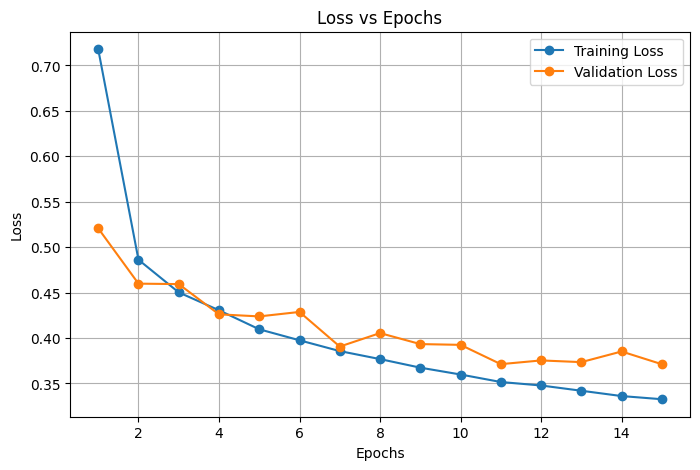

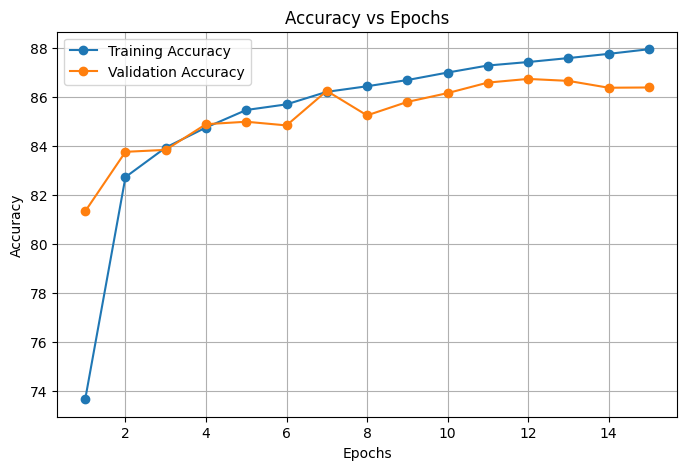

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(epochs,TrainLosses,marker='o',label='Training Loss')
plt.plot(epochs,ValLosses,marker='o',label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs,TrainAcc,marker='o',label='Training Accuracy')
plt.plot(epochs,ValAcc,marker='o',label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Testing the model on the testing dataset

In [ ]:
test_predictions = []
truelabels=[]
net.eval()
with torch.no_grad():
  for img, label in test:
    output = net(img)
    predict = torch.argmax(output,dim=1)
    test_predictions.extend(predict.numpy())
    truelabels.extend(label.numpy())
submission = pd.DataFrame({"ImageNo":range(1,len(test_predictions)+1),"PredictedLabel":test_predictions,"ActualLabel":truelabels})


In [ ]:
#Saving it in a CSV file
submission.to_csv("submission.csv",index = False)
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Saving model weights using pickle
with open('MyModel.pkl','wb') as fl:
  pickle.dump(net.state_dict(),fl)
